**IMPORT LIBRARIES**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**LOAD DATASET**

In [8]:
df = pd.read_csv("temperatures.csv")
print(df.head())

   YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
0  1901  22.40  24.14  29.07  31.91  33.41  33.18  31.21  30.39  30.47  29.97   
1  1902  24.93  26.58  29.77  31.78  33.73  32.91  30.92  30.73  29.80  29.12   
2  1903  23.44  25.03  27.83  31.39  32.91  33.00  31.34  29.98  29.85  29.04   
3  1904  22.50  24.73  28.21  32.02  32.64  32.07  30.36  30.09  30.04  29.20   
4  1905  22.00  22.83  26.68  30.01  33.32  33.25  31.44  30.68  30.12  30.67   

     NOV    DEC  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  
0  27.31  24.49   28.96    23.27    31.46    31.27    27.25  
1  26.31  24.04   29.22    25.75    31.76    31.09    26.49  
2  26.08  23.65   28.47    24.24    30.71    30.92    26.26  
3  26.36  23.63   28.49    23.62    30.95    30.66    26.40  
4  27.52  23.82   28.30    22.25    30.00    31.33    26.57  


**DATA PRE-PROCESSING**

In [9]:
# Convert month columns into long format
df_melt = df.melt(id_vars=['YEAR'], 
                  var_name='MONTH', 
                  value_name='TEMP')

# Map months to numbers
month_map = {
    'JAN':1,'FEB':2,'MAR':3,'APR':4,'MAY':5,'JUN':6,
    'JUL':7,'AUG':8,'SEP':9,'OCT':10,'NOV':11,'DEC':12
}

df_melt['MONTH_NUM'] = df_melt['MONTH'].map(month_map)

# Drop missing values
df_melt = df_melt.dropna()

print(df_melt.head())

   YEAR MONTH   TEMP  MONTH_NUM
0  1901   JAN  22.40        1.0
1  1902   JAN  24.93        1.0
2  1903   JAN  23.44        1.0
3  1904   JAN  22.50        1.0
4  1905   JAN  22.00        1.0


**DEFINE TARGET**

In [10]:
X = df_melt[['MONTH_NUM']]
y = df_melt['TEMP']

**TRAINING LINEAR REGRESSION MODEL**

In [11]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**PREDICTION**

In [12]:
y_pred = model.predict(X)

**MODEL EVALUATION**

In [13]:
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 10.138413546423767
MAE: 2.6878642126576593
R2 Score: 0.001971797874375514


**PLOYNOMIAL REGRESSION MODEL**

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MSE:", mean_squared_error(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))
print("R2 Score:", r2_score(y, y_pred))

MSE: 1.2574481544524014
MAE: 0.9007984740156497
R2 Score: 0.8762164597934562


**VISUALIZTION USING POLUNOMIAL REGRESSION**

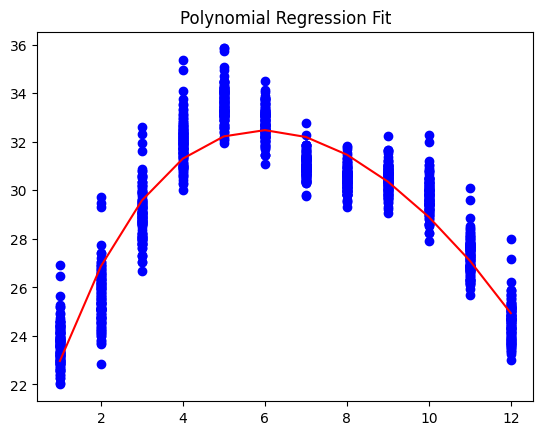

In [16]:
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X_poly), color='red')
plt.title("Polynomial Regression Fit")
plt.show()

**VISUALIZATION USING LINEAR REGRESSION**

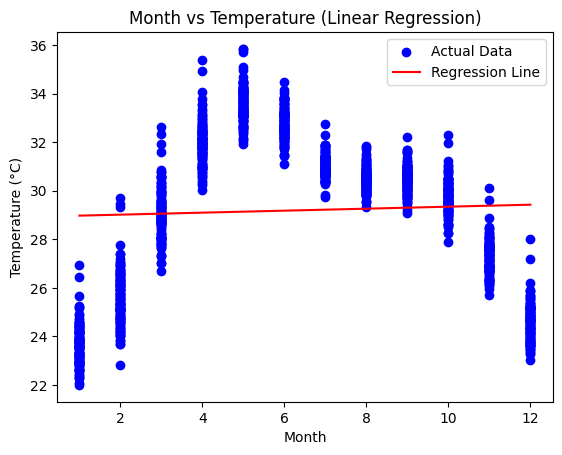

In [14]:
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Regression Line')

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Month vs Temperature (Linear Regression)")
plt.legend()

plt.show()